In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# show all columns
pd.options.display.max_columns = None


# Preprocessing

In [24]:
rides = pd.read_csv('.\\Data\\rides.csv')
# rides.head()

In [25]:
teams = pd.read_csv('.\\Data\\teams.csv')
# teams.head()

In [ ]:
# get team names from teams table
rides = rides.merge(teams, on='team_id', how='left')

# Calculate True Mileage (half golden spoke miles)
rides['true_miles'] = rides['miles']
rides.loc[rides['golden_spoke'] == 'yes', 'true_miles'] = rides['true_miles']/2

# By Team

In [ ]:
#===========================
# entries by mode
#===========================
rides['name'].value_counts()

name
Byron Bay Headlands      31
Grandberg Fir Peaks      28
Philly Joel              22
Joshmont Jackalopes      19
Chandler Bings           18
Pukarville Treasurers    17
Hughville Wagoneers      15
Gruyère Grinders         15
Mirandaville Mallards    14
Daytona Beach Boys       13
Billville Jovyans        12
Bjornstad Bears           8
Florence Nightingales     6
Dahlberg Dall Sheep       3
Aguilera Ascent           2
Nardonia Stentors         2
DeSeelhorst Dragons       1
Sudsville Swimmers        1
Jorlette Coordinators     1
Name: count, dtype: int64

In [ ]:
#===========================
# total miles by team
#===========================
rides.groupby('name')[['true_miles']].sum().sort_values('true_miles', ascending=False)

,true_miles
name,
Philly Joel,1081.00
Grandberg Fir Peaks,438.42
Byron Bay Headlands,399.00
Billville Jovyans,266.00
Mirandaville Mallards,168.75
Hughville Wagoneers,156.40
Gruyère Grinders,156.00
Daytona Beach Boys,99.00
Joshmont Jackalopes,92.93


In [ ]:
#===========================
# total bike miles by team
#===========================
rides_bike = rides[rides['mode']=='E_Bike'].copy()
rides_bike.groupby('name')[['true_miles']].sum().sort_values('true_miles', ascending=False)

,true_miles
name,
Pukarville Treasurers,83.60
Joshmont Jackalopes,62.93
Bjornstad Bears,57.20
Byron Bay Headlands,15.00
Hughville Wagoneers,7.00


In [ ]:
#===========================
# total Walk_Run miles by team
#===========================
rides_bike = rides[rides['mode']=='Walk_Run'].copy()
rides_bike.groupby('name')[['true_miles']].sum().sort_values('true_miles', ascending=False)


,true_miles
name,
Chandler Bings,66.1
Mirandaville Mallards,29.5
Aguilera Ascent,11.0
Gruyère Grinders,6.0
Hughville Wagoneers,3.0


In [ ]:
#===========================
# total Stationary miles by team
#===========================
rides_bike = rides[rides['mode']=='Stationary_Bike'].copy()
rides_bike.groupby('name')[['true_miles']].sum().sort_values('true_miles', ascending=False)

,true_miles
name,
Mirandaville Mallards,61.25
Philly Joel,21.00
Daytona Beach Boys,5.00


# By Mode

In [ ]:
#===========================
# entries by mode
#===========================
rides['mode'].value_counts()

mode
Bike               151
E_Bike              40
Walk_Run            30
Stationary_Bike      7
Name: count, dtype: int64

In [ ]:
#===========================
# total miles by mode
#===========================
rides.groupby('mode')[['true_miles']].sum().sort_values('true_miles', ascending=False)

,true_miles
mode,
Bike,2768.32
E_Bike,225.73
Walk_Run,115.60
Stationary_Bike,87.25


In [ ]:
#===========================
# median miles by mode
#===========================
rides.groupby('mode')[['true_miles']].median().sort_values('true_miles', ascending=False)

,true_miles
mode,
Stationary_Bike,12.0
Bike,10.0
E_Bike,3.6
Walk_Run,3.0


In [ ]:
#===========================
# mean miles by mode
#===========================
rides.groupby('mode')[['true_miles']].mean().sort_values('true_miles', ascending=False)

,true_miles
mode,
Bike,18.333245
Stationary_Bike,12.464286
E_Bike,5.643250
Walk_Run,3.853333


# Charts using date column

In [18]:
rides['ride_date'] = pd.to_datetime(rides['ride_date'])
rides['ride_date2'] = rides['ride_date'].dt.date
rides_by_date = rides.groupby('ride_date2', as_index=False)[['miles']].sum()

rides_by_date = rides_by_date.sort_values('ride_date2') # IMPORTANT
rides_by_date['cumulative_miles'] = rides_by_date['miles'].cumsum()

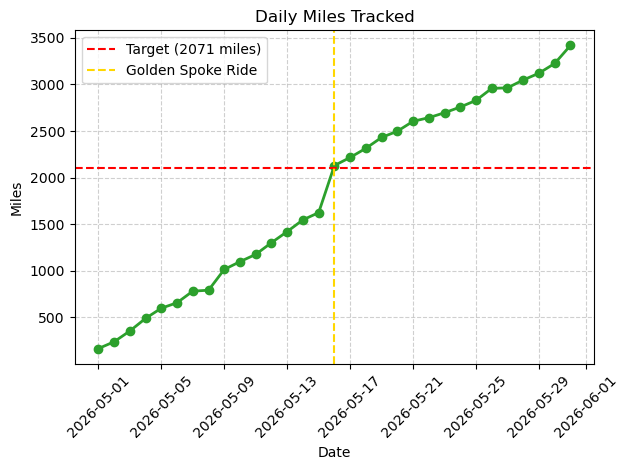

In [ ]:
plt.plot(rides_by_date['ride_date2'], rides_by_date['cumulative_miles'], marker='o', color='tab:green', linewidth=2)

#Formatting the labels and titles
plt.xlabel('Date')
plt.ylabel('Miles')
plt.title('Cumulative Miles Tracked')

# Clean up the Date appearance on the X-axis
# This formats the dates cleanly as YYYY-MM-DD and rotates them so they don't overlap
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Adds a clean grid and automatically adjusts padding
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.axhline(y=2100, color='r', linestyle='--', linewidth=1.5, label='Target (2071 miles)')
plt.axvline(x=pd.to_datetime('2026-05-16'), color='gold', linestyle='--', linewidth=1.5, label='Golden Spoke Ride')
plt.legend()
plt.show()

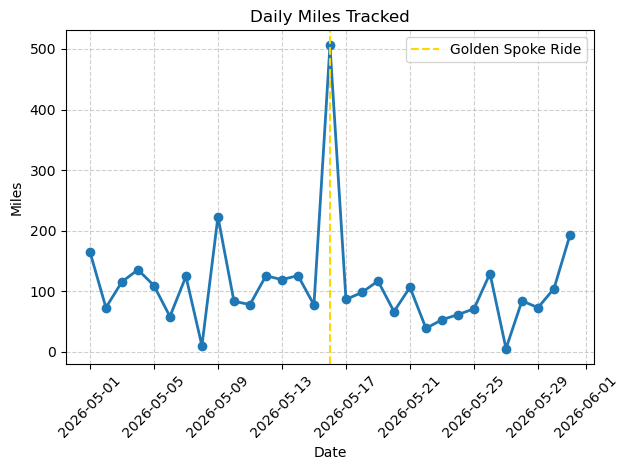

In [ ]:
plt.plot(rides_by_date['ride_date2'], rides_by_date['miles'], marker='o', color='tab:blue', linewidth=2)

# Formatting the labels and titles
plt.xlabel('Date')
plt.ylabel('Miles')
plt.title('Daily Miles Tracked')

# Clean up the Date appearance on the X-axis
# This formats the dates cleanly as YYYY-MM-DD and rotates them so they don't overlap
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Adds a clean grid and automatically adjusts padding
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.axvline(x=pd.to_datetime('2026-05-16'), color='gold', linestyle='--', linewidth=1.5, label='Golden Spoke Ride')
plt.legend()
plt.show()